In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Data/output.csv")

In [3]:
df.head()

,timestamp,level,user_id,action,latency_ms,error_code
0,2026-09-20 22:42:58,WARN,user_939,add_cart,58,0
1,2026-09-20 22:42:59,WARN,user_779,view_item,915,0
2,2026-09-20 22:43:01,INFO,user_150,view_item,92,0
3,2026-09-20 22:43:02,INFO,user_600,login,89,0
4,2026-09-20 22:43:03,INFO,user_283,pay,25,0


In [4]:
df["level"].value_counts()

level
INFO     16
WARN      2
ERROR     2
Name: count, dtype: int64

In [5]:
df["action"].value_counts()

action
add_cart     6
view_item    5
pay          5
login        4
Name: count, dtype: int64

In [6]:
df["latency_ms"].mean()

np.float64(204.55)

In [7]:
df["latency_ms"].median()

np.float64(63.0)

In [8]:
df["latency_ms"].max()

np.int64(1166)

In [9]:
df["latency_ms"].min()

np.int64(22)

In [10]:
df["latency_ms"].quantile(0.95)

np.float64(1033.95)

In [11]:
df.groupby("action")["latency_ms"].agg(["mean", "max"])

,mean,max
action,,
add_cart,236.666667,1166
login,311.250000,1027
pay,45.600000,62
view_item,239.600000,915


In [12]:
error_quantity = (df["level"] == "ERROR").sum()
error_quantity / len(df)

np.float64(0.1)

In [13]:
slow_quantity = (df["latency_ms"] > 800).sum()
slow_quantity / len(df)

np.float64(0.15)

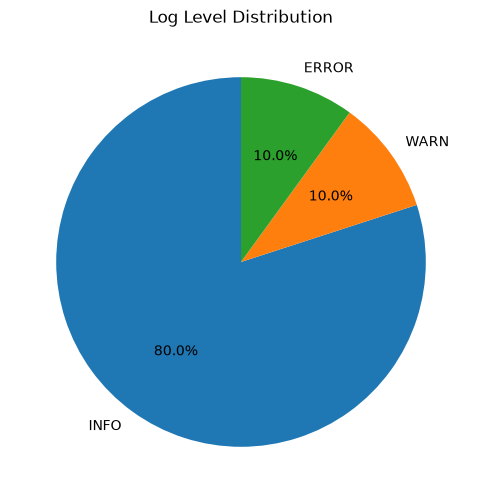

In [16]:
level_counts = df["level"].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(level_counts, labels=level_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Log Level Distribution")
plt.savefig("../Data/level_pie.png")
plt.show()